In [1]:
import numpy as np
import pandas as pd

In [2]:
data=pd.read_csv("MicrosoftStock.csv")

In [3]:
data.head()

,index,date,open,high,low,close,volume,Name
0,390198,2013-02-08,27.35,27.71,27.31,27.55,33318306,MSFT
1,390199,2013-02-11,27.65,27.92,27.50,27.86,32247549,MSFT
2,390200,2013-02-12,27.88,28.00,27.75,27.88,35990829,MSFT
3,390201,2013-02-13,27.93,28.11,27.88,28.03,41715530,MSFT
4,390202,2013-02-14,27.92,28.06,27.87,28.04,32663174,MSFT


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1259 entries, 0 to 1258
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   index   1259 non-null   int64  
 1   date    1259 non-null   object 
 2   open    1259 non-null   float64
 3   high    1259 non-null   float64
 4   low     1259 non-null   float64
 5   close   1259 non-null   float64
 6   volume  1259 non-null   int64  
 7   Name    1259 non-null   object 
dtypes: float64(4), int64(2), object(2)
memory usage: 78.8+ KB


In [5]:
data['date']=pd.to_datetime(data['date'])

In [6]:
data.set_index('date',inplace=True)

In [7]:
data.head()

,index,open,high,low,close,volume,Name
date,,,,,,,
2013-02-08,390198,27.35,27.71,27.31,27.55,33318306,MSFT
2013-02-11,390199,27.65,27.92,27.50,27.86,32247549,MSFT
2013-02-12,390200,27.88,28.00,27.75,27.88,35990829,MSFT
2013-02-13,390201,27.93,28.11,27.88,28.03,41715530,MSFT
2013-02-14,390202,27.92,28.06,27.87,28.04,32663174,MSFT


In [8]:
price=data['close']

In [9]:
from statsmodels.tsa.stattools import adfuller,kpss

In [10]:
adf_test=adfuller(data['close'])

In [11]:
print(f" adf_statistics {round(adf_test[0],3)}")
print(f" p-value {round(adf_test[1],3)}") #Non stattionarity present in data

 adf_statistics 0.416
 p-value 0.982


In [12]:
for key,value in adf_test[4].items():
    print(f"{key}:{round(value,3)}")

1%:-3.436
5%:-2.864
10%:-2.568


In [13]:
result = adfuller(data['close'])

print("ADF Statistic:", result[0])
print("p-value:", result[1])
print("Lags used:", result[2])
print("Observations:", result[3])
print("Critical values:", result[4])

ADF Statistic: 0.41565522923568116
p-value: 0.9820710439125857
Lags used: 0
Observations: 1258
Critical values: {'1%': np.float64(-3.4355588184378574), '5%': np.float64(-2.8638402312881497), '10%': np.float64(-2.5679946684494275)}


In [15]:
#ADF statistic<Critical value then series is stationarity

<Axes: xlabel='date'>

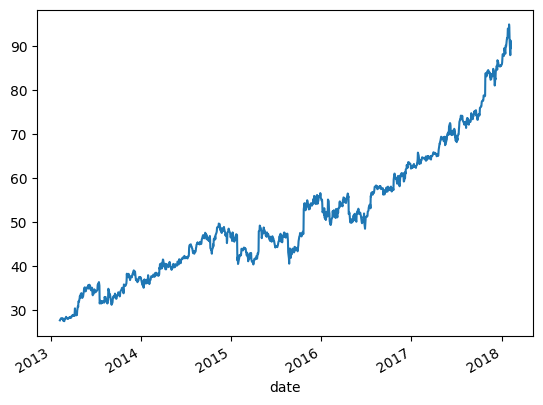

In [16]:
price.plot()

In [17]:
kpss_test=kpss(data['close'],regression='ct')

C:\Users\Mcc\AppData\Local\Temp\ipykernel_32156\3465776723.py:1: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_test=kpss(data['close'],regression='ct')


In [18]:
print(f"adf stats:{round(kpss_test[0],3)}")
print(f"p-value stats:{round(kpss_test[1],3)}")
for key,value in kpss_test[3].items():
    print(f"{key}:{round(value,3)}")

adf stats:0.877
p-value stats:0.01
10%:0.119
5%:0.146
2.5%:0.176
1%:0.216


In [19]:
# KPSS statistic<Critical value Fail to reject H0

# → Evidence that the series is stationary.

In [17]:
from scipy import signal

In [20]:
#numpy.polyfit(x, y, deg)
trend=np.polyfit(np.arange(len(price)),price,1)
trendline=np.polyval(trend,np.arange(len(price)))
#numpy.polyval(polynomial coefficient, x)
price_detrended=price-trendline

In [21]:
trend

array([ 0.03876711, 26.67857011])

In [22]:
trendline

array([26.67857011, 26.71733722, 26.75610433, ..., 75.37005691,
       75.40882402, 75.44759113], shape=(1259,))

In [23]:
price_detrended

date
2013-02-08     0.871430
2013-02-11     1.142663
2013-02-12     1.123896
2013-02-13     1.235129
2013-02-14     1.206361
                ...    
2018-02-01    18.967477
2018-02-02    16.448710
2018-02-05    12.629943
2018-02-06    15.921176
2018-02-07    14.162409
Name: close, Length: 1259, dtype: float64

In [24]:
import matplotlib.pyplot as plt

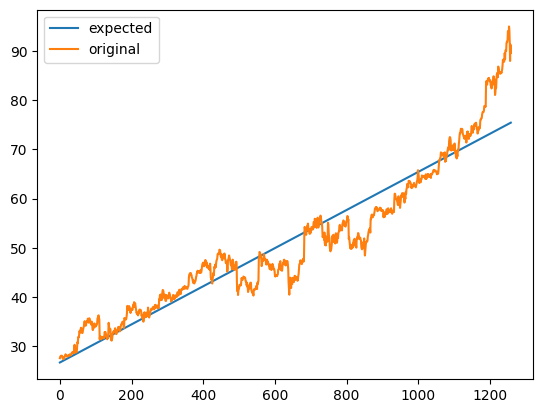

In [25]:
plt.plot(np.arange(len(price)),trendline,label='expected')
plt.plot(np.arange(len(price)),price,label='original')
plt.legend()
plt.show()

In [26]:
adfuller(price_detrended)[1]

np.float64(0.3680491805652386)

In [27]:
window=12
price_ma=price.rolling(window=window).mean()
price_detrended=price-price_ma
price_detrended=price_detrended.dropna()

In [28]:
price_detrended

date
2013-02-26   -0.402917
2013-02-27    0.015417
2013-02-28    0.010417
2013-03-01    0.154583
2013-03-04    0.344583
                ...   
2018-02-01    1.935833
2018-02-02   -0.680833
2018-02-05   -4.285833
2018-02-06   -1.066667
2018-02-07   -2.620000
Name: close, Length: 1248, dtype: float64

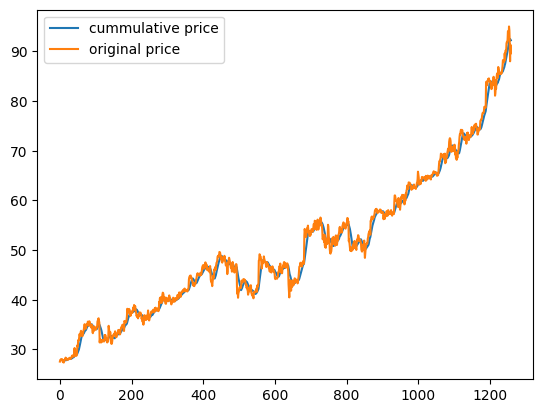

In [29]:
plt.plot(np.arange(len(price)),price_ma,label='cummulative price')
plt.plot(np.arange(len(price)),price,label='original price')
plt.legend()
plt.show() #movingaverage detrending

In [31]:
# 1. White noise
# White noise is a series consisting of completely random fluctuations with no predictable pattern.
# A simple white-noise process is:
# Yt=ϵt
# where ϵt is random noise.
# For white noise, we typically assume:
# Mean is constant, usually 0
# Variance is constant
# No autocorrelation between different time periods
# Observations are unpredictable from previous observations
# Is white noise stationary?
# Yes.
# White noise is generally considered stationary.
# Its mean and variance remain constant, and its autocorrelation is approximately zero for non-zero lags.
#----------------------------------------------------------------------------------------------------------------------------
# 2. Random walk
# A random walk is very different.

# It is defined as:

# Yt=Y(t−1)+ϵt
# where 
# ϵt is white noise.
# So the variance increases with time.

# Therefore, the random walk is non-stationary.




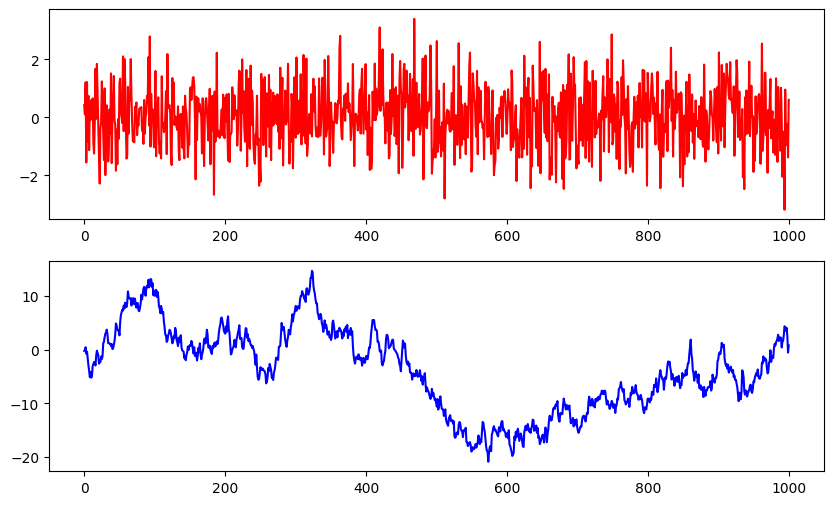

In [32]:
white_noise=np.random.normal(0,1,1000)
random_shocks=np.random.normal(0,1,1000)
random_walk=np.cumsum(random_shocks)
plt.figure(figsize=(10,6))
plt.subplot(2,1,1)
plt.plot(white_noise,color='red')
plt.subplot(2,1,2)
plt.plot(random_walk,color='blue')

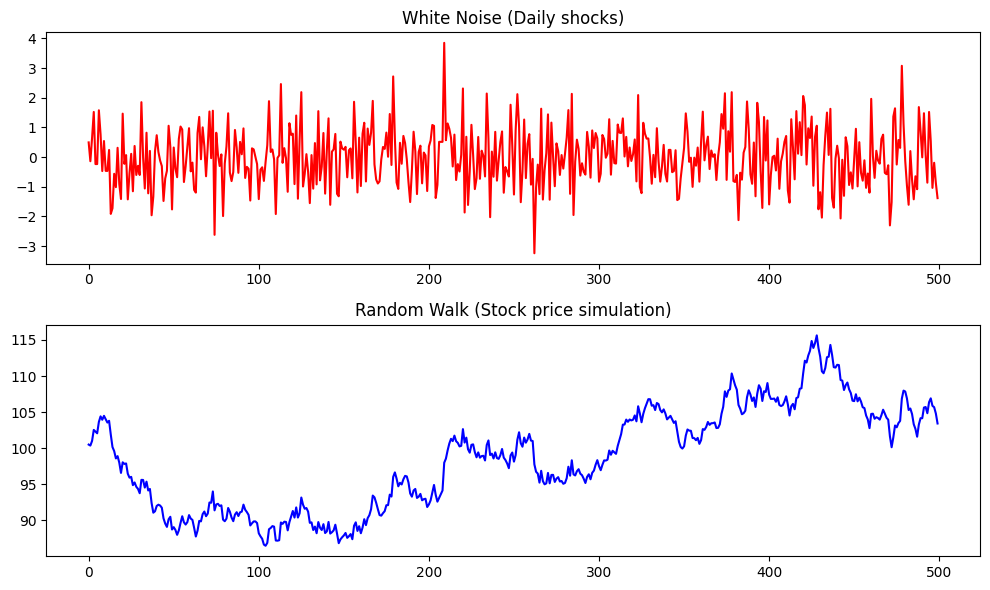

In [33]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)  # reproducibility

n = 500

# 1. White noise (daily news / shocks)
white_noise = np.random.normal(0, 1, n)

# 2. Random walk (stock price)
stock_price = 100 + np.cumsum(white_noise)

# 3. Plot
plt.figure(figsize=(10,6))

plt.subplot(2,1,1)
plt.plot(white_noise, color='red')
plt.title("White Noise (Daily shocks)")

plt.subplot(2,1,2)
plt.plot(stock_price, color='blue')
plt.title("Random Walk (Stock price simulation)")

plt.tight_layout()
plt.show()

In [34]:
price=data['close']

In [35]:
#autoregressive model

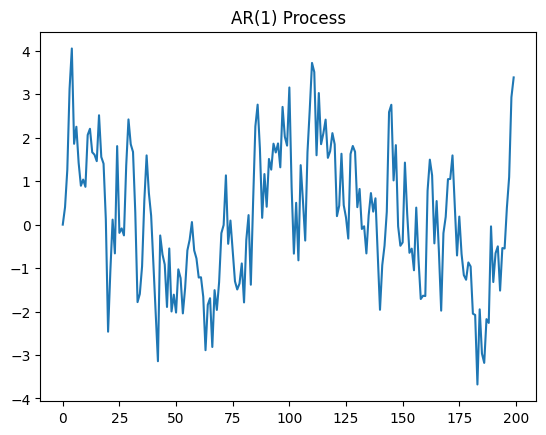

In [36]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(0)

n = 200
noise = np.random.normal(0, 1, n)

x = np.zeros(n)

# AR(1): x[t] = 0.7*x[t-1] + noise
for t in range(1, n):
    x[t] = 0.7 * x[t-1] + noise[t]

plt.plot(x)
plt.title("AR(1) Process")
plt.show()

In [37]:
data.head()

,index,open,high,low,close,volume,Name
date,,,,,,,
2013-02-08,390198,27.35,27.71,27.31,27.55,33318306,MSFT
2013-02-11,390199,27.65,27.92,27.50,27.86,32247549,MSFT
2013-02-12,390200,27.88,28.00,27.75,27.88,35990829,MSFT
2013-02-13,390201,27.93,28.11,27.88,28.03,41715530,MSFT
2013-02-14,390202,27.92,28.06,27.87,28.04,32663174,MSFT


In [38]:
opens=data['open']

In [39]:
adf_test=adfuller(opens)

In [40]:
adf_test[1]

np.float64(0.9876246263021329)

In [41]:
open_dff=opens.diff()

In [42]:
adf_test=adfuller(open_dff.dropna())

In [43]:
adf_test[1]

0.0

In [44]:

main_data=open_dff.dropna()

In [45]:
import numpy as np

x = np.arange(len(main_data))

trend = np.polyfit(x,main_data, 1)
trendline = np.polyval(trend, x)

price_detrended = main_data - trendline

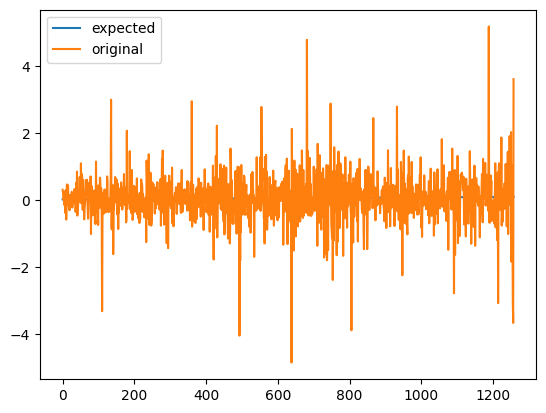

In [46]:
plt.plot(np.arange(len(main_data)),trendline,label='expected')
plt.plot(np.arange(len(main_data)),main_data,label='original')
plt.legend()
plt.show()

In [47]:
from statsmodels.tsa.ar_model import AutoReg

model = AutoReg(main_data, lags=2)   # AR(2)
model_fit = model.fit()

print(model_fit.params)

const      0.053982
open.L1   -0.055100
open.L2   -0.030489
dtype: float64


C:\Users\Mcc\AppData\Roaming\Python\Python310\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


In [48]:
len(main_data)

1258

In [49]:
x_train,x_test=main_data[:1000],main_data[1000:]

In [50]:
x_train

date
2013-02-11    0.30
2013-02-12    0.23
2013-02-13    0.05
2013-02-14   -0.01
2013-02-15    0.12
              ... 
2017-01-24    0.50
2017-01-25    0.75
2017-01-26    0.17
2017-01-27    1.27
2017-01-30    0.30
Name: open, Length: 1000, dtype: float64

In [51]:
x_test

date
2017-01-31   -0.830
2017-02-01   -0.505
2017-02-02   -1.105
2017-02-03    0.250
2017-02-06    0.000
              ...  
2018-02-01    1.040
2018-02-02   -1.150
2018-02-05   -3.080
2018-02-06   -3.670
2018-02-07    3.600
Name: open, Length: 258, dtype: float64

In [52]:
from statsmodels.tsa.ar_model import AutoReg
from sklearn.metrics import mean_squared_error

In [53]:
model_ar = AutoReg(x_train, lags=180) 

C:\Users\Mcc\AppData\Roaming\Python\Python310\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


In [54]:
model_fit=model_ar.fit()

In [55]:
predictions=model_fit.predict(
    start=len(x_train),
    end=len(x_train)+len(x_test)-1,
    dynamic=False
)

C:\Users\Mcc\AppData\Roaming\Python\Python310\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\Mcc\AppData\Roaming\Python\Python310\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(
C:\Users\Mcc\AppData\Roaming\Python\Python310\site-packages\statsmodels\tsa\deterministic.py:308: UserWarning: Only PeriodIndexes, DatetimeIndexes with a frequency set, RangesIndexes, and Index with a unit increment support extending. The index is set will contain the position relative to the data length.
  fcast_index = self._extend_index(index, steps, forecast_index)


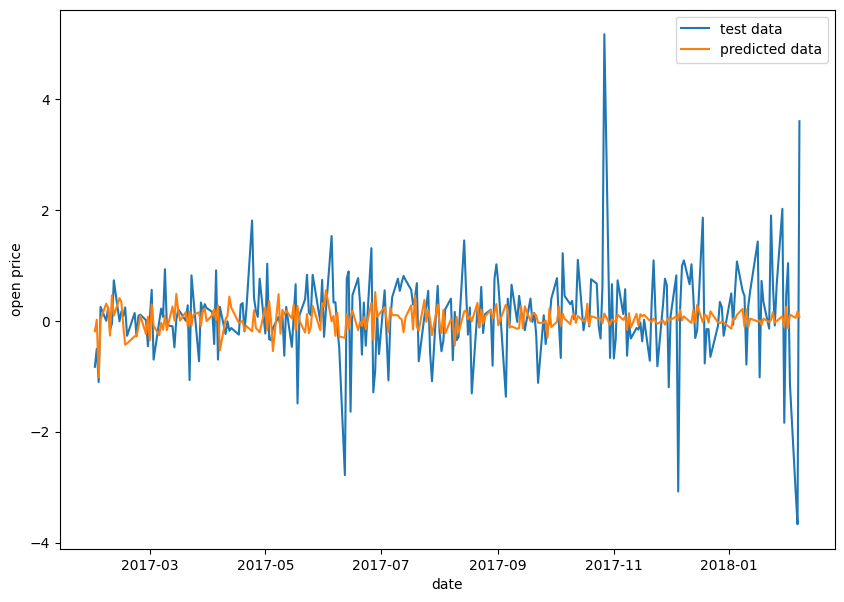

In [56]:
plt.figure(figsize=(10,7))
plt.plot(x_test.index,x_test,label='test data')
plt.plot(x_test.index,predictions,label='predicted data')
plt.xlabel('date')
plt.ylabel('open price')
plt.legend()
plt.show()

In [57]:
data=pd.read_csv('Electric_Production.csv')

In [58]:
data.head()

,DATE,IPG2211A2N
0,1/1/1985,72.5052
1,2/1/1985,70.6720
2,3/1/1985,62.4502
3,4/1/1985,57.4714
4,5/1/1985,55.3151


In [59]:
data['DATE']=pd.to_datetime(data['DATE'])

In [60]:
data.set_index('DATE',inplace=True)

In [61]:
data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 397 entries, 1985-01-01 to 2018-01-01
Data columns (total 1 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   IPG2211A2N  397 non-null    float64
dtypes: float64(1)
memory usage: 6.2 KB


In [62]:
from statsmodels.tsa.stattools import adfuller,kpss

In [63]:
adf_test=adfuller(data['IPG2211A2N'])

In [64]:
adf_test[1]

np.float64(0.18621469116586592)

In [65]:
col1=data['IPG2211A2N'].diff().dropna()

In [66]:
adf_test=adfuller(col1)

In [67]:
adf_test[1]

np.float64(4.0777865655394095e-10)

In [68]:
x_train,x_test=col1[:250],col1[250:]

In [69]:
x_train,x_test

(DATE
 1985-02-01    -1.8332
 1985-03-01    -8.2218
 1985-04-01    -4.9788
 1985-05-01    -2.1563
 1985-06-01     2.7753
                ...   
 2005-07-01     8.8425
 2005-08-01     1.1361
 2005-09-01   -10.3707
 2005-10-01    -9.3588
 2005-11-01     0.7020
 Name: IPG2211A2N, Length: 250, dtype: float64,
 DATE
 2005-12-01    17.7670
 2006-01-01    -3.7533
 2006-02-01    -2.9528
 2006-03-01    -3.1179
 2006-04-01   -10.8924
                ...   
 2017-09-01   -10.3158
 2017-10-01    -5.0017
 2017-11-01     3.7222
 2017-12-01    17.3853
 2018-01-01    14.6836
 Name: IPG2211A2N, Length: 146, dtype: float64)

In [70]:
from statsmodels.tsa.ar_model import AutoReg
from sklearn.metrics import mean_squared_error

In [71]:
model1 = AutoReg(x_train, lags=50).fit()

C:\Users\Mcc\AppData\Roaming\Python\Python310\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


In [72]:
start = len(x_train)
end = len(x_train) + len(x_test) - 1
print(start,end)


250 395


In [73]:
predictions=model1.predict(
    start=len(x_train),
    end=len(x_train)+len(x_test)-1,
    dynamic=False
)

C:\Users\Mcc\AppData\Roaming\Python\Python310\site-packages\statsmodels\tsa\deterministic.py:308: UserWarning: Only PeriodIndexes, DatetimeIndexes with a frequency set, RangesIndexes, and Index with a unit increment support extending. The index is set will contain the position relative to the data length.
  fcast_index = self._extend_index(index, steps, forecast_index)


In [74]:
predictions=model1.predict(
    start=len(x_train),
    end=len(x_train)+len(x_test)-1,
    dynamic=True
)

C:\Users\Mcc\AppData\Roaming\Python\Python310\site-packages\statsmodels\tsa\deterministic.py:308: UserWarning: Only PeriodIndexes, DatetimeIndexes with a frequency set, RangesIndexes, and Index with a unit increment support extending. The index is set will contain the position relative to the data length.
  fcast_index = self._extend_index(index, steps, forecast_index)


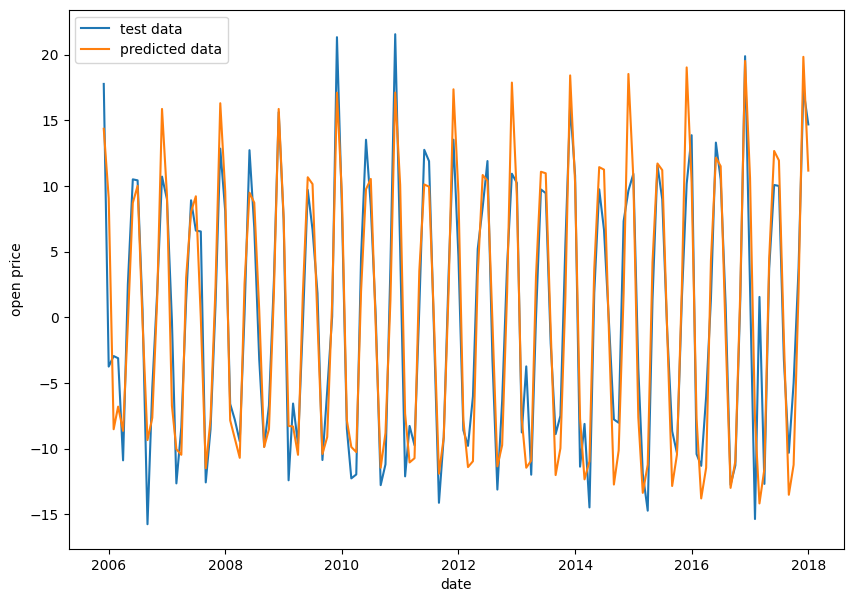

In [75]:
plt.figure(figsize=(10,7))
plt.plot(x_test.index,x_test,label='test data')
plt.plot(x_test.index,predictions,label='predicted data')
plt.xlabel('date')
plt.ylabel('open price')
plt.legend()
plt.show()

In [76]:
print(f"rmse error {np.sqrt(mean_squared_error(x_test,predictions))}")

rmse error 3.5663720713845226


ARIMA mode

In [77]:
from statsmodels.tsa.arima.model import ARIMA

In [78]:
model_ma = ARIMA(x_train, order=(0,0,10)).fit()

C:\Users\Mcc\AppData\Roaming\Python\Python310\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\Mcc\AppData\Roaming\Python\Python310\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\Mcc\AppData\Roaming\Python\Python310\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\Mcc\AppData\Roaming\Python\Python310\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [79]:
start = len(x_train)
end = len(x_train) + len(x_test) - 1
print(start,end)

250 395


In [80]:
predictions=model_ma.predict(
    start=len(x_train),
    end=len(x_train)+len(x_test)-1,
    dynamic=False
)

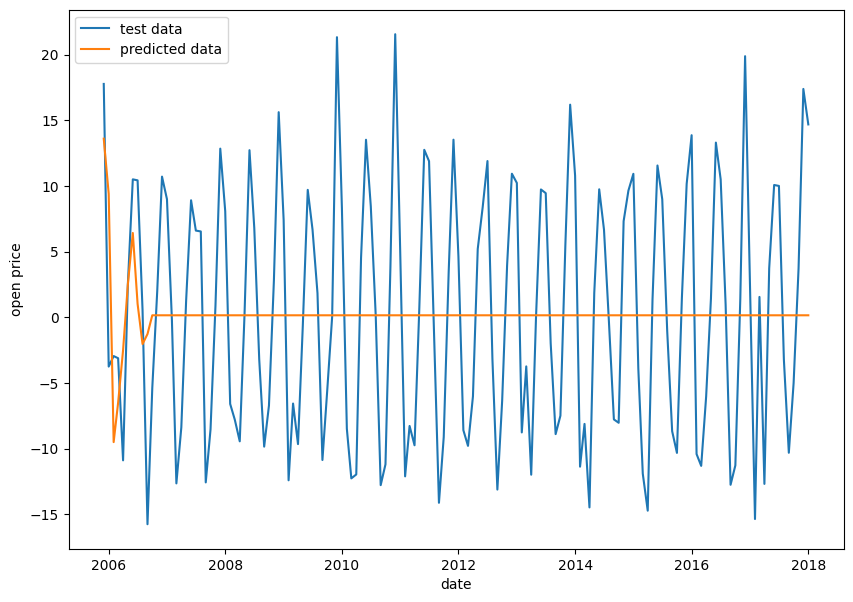

rmse error 9.311429746694607


In [81]:
plt.figure(figsize=(10,7))
plt.plot(x_test.index,x_test,label='test data')
plt.plot(x_test.index,predictions,label='predicted data')
plt.xlabel('date')
plt.ylabel('open price')
plt.legend()
plt.show()
print(f"rmse error {np.sqrt(mean_squared_error(x_test,predictions))}")

In [82]:
model_arma = ARIMA(x_train, order=(7,0,7)).fit()

C:\Users\Mcc\AppData\Roaming\Python\Python310\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\Mcc\AppData\Roaming\Python\Python310\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\Mcc\AppData\Roaming\Python\Python310\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\Mcc\AppData\Roaming\Python\Python310\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [83]:
start = len(x_train)
end = len(x_train) + len(x_test) - 1
print(start,end)

250 395


In [84]:
predictions=model_arma.predict(
    start=len(x_train),
    end=len(x_train)+len(x_test)-1,
    dynamic=False
)

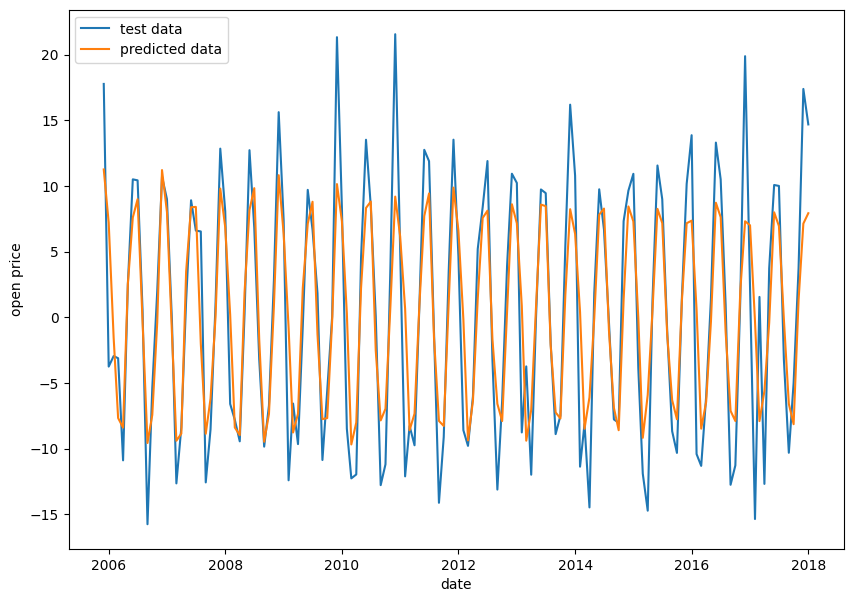

rmse error 4.726696765589285


In [85]:
plt.figure(figsize=(10,7))
plt.plot(x_test.index,x_test,label='test data')
plt.plot(x_test.index,predictions,label='predicted data')
plt.xlabel('date')
plt.ylabel('open price')
plt.legend()
plt.show()
print(f"rmse error {np.sqrt(mean_squared_error(x_test,predictions))}")

In [86]:
model_arima = ARIMA(x_train, order=(7,1,7)).fit()

C:\Users\Mcc\AppData\Roaming\Python\Python310\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\Mcc\AppData\Roaming\Python\Python310\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\Mcc\AppData\Roaming\Python\Python310\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\Mcc\AppData\Roaming\Python\Python310\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
C:\Users\Mcc\AppData\Roaming\Python\Python310\site-packages\statsmodels\base\mod

In [87]:
start = len(x_train)
end = len(x_train) + len(x_test) - 1
print(start,end)

250 395


In [88]:
predictions=model_arima.predict(
    start=len(x_train),
    end=len(x_train)+len(x_test)-1,
    dynamic=False
)

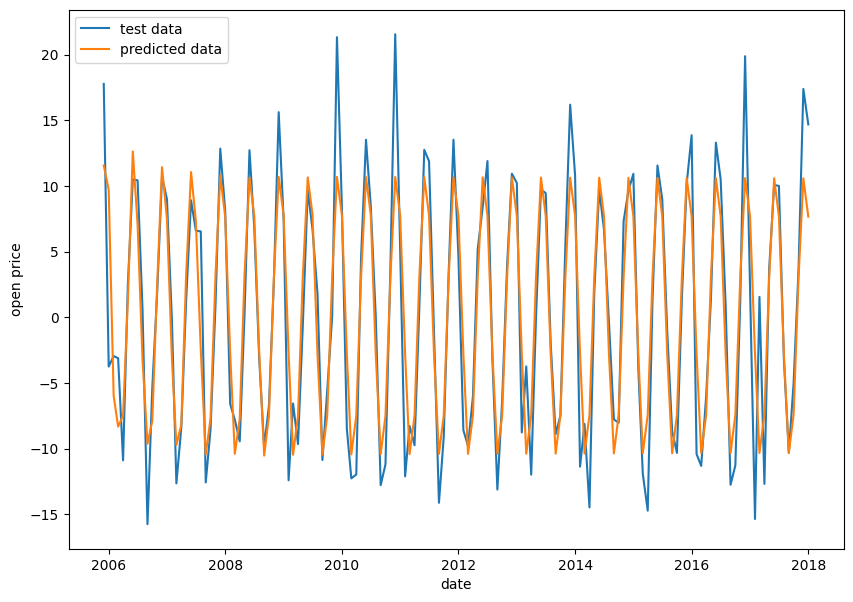

rmse error 4.0495490221889865


In [89]:
plt.figure(figsize=(10,7))
plt.plot(x_test.index,x_test,label='test data')
plt.plot(x_test.index,predictions,label='predicted data')
plt.xlabel('date')
plt.ylabel('open price')
plt.legend()
plt.show()
print(f"rmse error {np.sqrt(mean_squared_error(x_test,predictions))}")

In [90]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

model = SARIMAX(
    x_train,
    order=(1,1,1),
    seasonal_order=(1,1,1,12)
)

model_fit = model.fit()

C:\Users\Mcc\AppData\Roaming\Python\Python310\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\Mcc\AppData\Roaming\Python\Python310\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


In [91]:
start = len(x_train)
end = len(x_train) + len(x_test) - 1
print(start,end)

250 395


In [92]:
predictions=model_fit.predict(
    start=len(x_train),
    end=len(x_train)+len(x_test)-1,
    dynamic=False
)

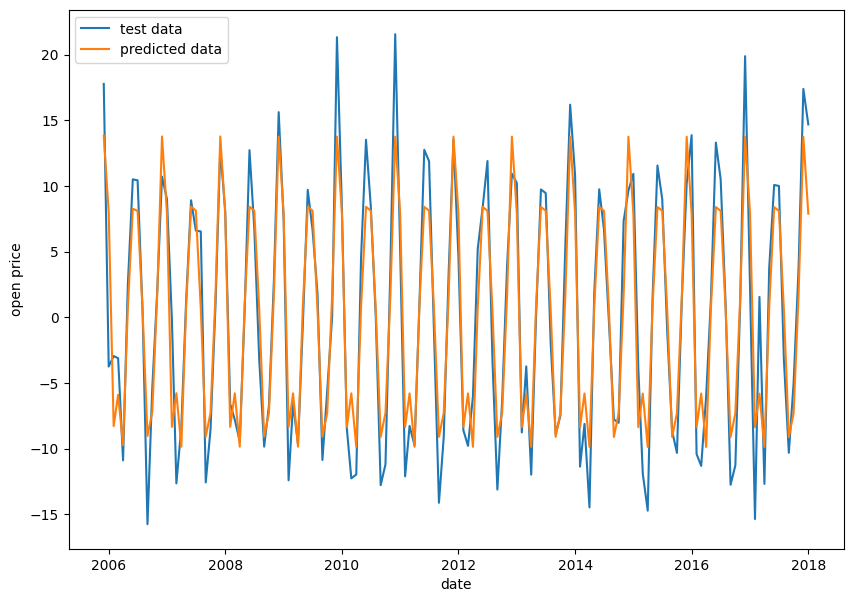

rmse error 3.3790626037178164


In [93]:
plt.figure(figsize=(10,7))
plt.plot(x_test.index,x_test,label='test data')
plt.plot(x_test.index,predictions,label='predicted data')
plt.xlabel('date')
plt.ylabel('open price')
plt.legend()
plt.show()
print(f"rmse error {np.sqrt(mean_squared_error(x_test,predictions))}")

vector models

In [327]:
from statsmodels.tsa.stattools import grangercausalitytests

In [337]:
x=data[['high','close']] #order matters here

In [338]:
grangercausalitytests(x, maxlag=3) #p==0 means highly affected


Granger Causality
number of lags (no zero) 1
ssr based F test:         F=264.9844, p=0.0000  , df_denom=1255, df_num=1
ssr based chi2 test:   chi2=265.6178, p=0.0000  , df=1
likelihood ratio test: chi2=240.9881, p=0.0000  , df=1
parameter F test:         F=264.9844, p=0.0000  , df_denom=1255, df_num=1

Granger Causality
number of lags (no zero) 2
ssr based F test:         F=138.4549, p=0.0000  , df_denom=1252, df_num=2
ssr based chi2 test:   chi2=278.0157, p=0.0000  , df=2
likelihood ratio test: chi2=251.1645, p=0.0000  , df=2
parameter F test:         F=138.4549, p=0.0000  , df_denom=1252, df_num=2

Granger Causality
number of lags (no zero) 3
ssr based F test:         F=92.6722 , p=0.0000  , df_denom=1249, df_num=3
ssr based chi2 test:   chi2=279.5748, p=0.0000  , df=3
likelihood ratio test: chi2=252.4217, p=0.0000  , df=3
parameter F test:         F=92.6722 , p=0.0000  , df_denom=1249, df_num=3


{np.int64(1): ({'ssr_ftest': (np.float64(264.98440945077897),
    np.float64(3.3504381888831683e-54),
    np.float64(1255.0),
    np.int64(1)),
   'ssr_chi2test': (np.float64(265.617838317992),
    np.float64(1.023318392051929e-59),
    np.int64(1)),
   'lrtest': (np.float64(240.98814764420058),
    np.float64(2.3946775343570995e-54),
    np.int64(1)),
   'params_ftest': (np.float64(264.9844094507788),
    np.float64(3.3504381888831683e-54),
    np.float64(1255.0),
    1.0)},
   array([[0., 1., 0.]])]),
 np.int64(2): ({'ssr_ftest': (np.float64(138.45489030532343),
    np.float64(4.7562667619550275e-55),
    np.float64(1252.0),
    np.int64(2)),
   'ssr_chi2test': (np.float64(278.0156503415201),
    np.float64(4.262541172824878e-61),
    np.int64(2)),
   'lrtest': (np.float64(251.16449733091758),
    np.float64(2.8861731330488353e-55),
    np.int64(2)),
   'params_ftest': (np.float64(138.45489030532354),
    np.float64(4.7562667619550275e-55),
    np.float64(1252.0),
    2.0)},
   array

In [339]:
y=data[['high','close']].diff().dropna()

In [340]:
y=y.to_numpy()

In [341]:
from statsmodels.tsa.api import VAR,VARMAX

In [342]:
train_data,test_data=y[:1000],y[1000:]

In [343]:
model = VAR(train_data)

In [344]:
lag_results = model.select_order(maxlags=10)
print(lag_results.summary())


 VAR Order Selection (* highlights the minimums)  
       AIC         BIC         FPE         HQIC   
--------------------------------------------------
0       -2.710      -2.700     0.06655      -2.706
1       -3.104      -3.074     0.04489      -3.092
2       -3.184      -3.135     0.04142      -3.165
3       -3.234      -3.165     0.03939      -3.208
4       -3.276      -3.187     0.03778      -3.242
5       -3.299     -3.190*     0.03691      -3.258
6       -3.308      -3.179     0.03660     -3.259*
7       -3.313      -3.165     0.03641      -3.257
8       -3.322      -3.153     0.03610      -3.258
9       -3.321      -3.133     0.03611      -3.250
10     -3.335*      -3.127    0.03563*      -3.256
--------------------------------------------------


In [345]:
var_model = model.fit(2)
print(var_model.summary())

  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Fri, 17, Apr, 2026
Time:                     17:42:21
--------------------------------------------------------------------
No. of Equations:         2.00000    BIC:                   -3.14738
Nobs:                     998.000    HQIC:                  -3.17785
Log likelihood:          -1227.13    FPE:                  0.0409036
AIC:                     -3.19654    Det(Omega_mle):       0.0404968
--------------------------------------------------------------------
Results for equation y1
           coefficient       std. error           t-stat            prob
------------------------------------------------------------------------
const         0.032521         0.017874            1.820           0.069
L1.y1        -0.494344         0.057254           -8.634           0.000
L1.y2         0.601214         0.048338           12.438           0.000
L2.y1        -0.214832

In [346]:
data.columns

Index(['index', 'date', 'open', 'high', 'low', 'close', 'volume', 'Name',
       'year', 'month'],
      dtype='object')

In [347]:
# Get last observations

# Forecast next 5 steps
forecast = var_model.forecast(y=test_data, steps=5)

forecast_df = pd.DataFrame(forecast, columns=[['high','close']])
print(forecast_df)

       high     close
0  0.068558  0.131270
1 -0.418034  0.047763
2  0.286147  0.005244
3 -0.003972  0.065702
4  0.013830  0.027832


In [348]:
# 1. Split data FIRST
train_data, test_data = y[:1000], y[1000:]

# 2. Build VAR model
model = VAR(train_data)



lag_results = model.select_order(maxlags=10) # 3. Select lag order #It tries different lag lengths (0 to 10) and checks:
# “Which lag length gives the best model?”
print(lag_results.summary())

# 4. Fit model (choose lag = 2 or best from above)
var_model = model.fit(5)
print(var_model.summary())

# 5. Get lag order
lag_order = var_model.k_ar

# 6. Get last observations from TRAIN data (NOT test data)
forecast_input = train_data[-lag_order:]

# 7. Forecast next steps
forecast = var_model.forecast(y=forecast_input, steps=5)

# 8. Convert to DataFrame
forecast_df = pd.DataFrame(forecast, columns=['high', 'close'])

print(forecast_df)

 VAR Order Selection (* highlights the minimums)  
       AIC         BIC         FPE         HQIC   
--------------------------------------------------
0       -2.710      -2.700     0.06655      -2.706
1       -3.104      -3.074     0.04489      -3.092
2       -3.184      -3.135     0.04142      -3.165
3       -3.234      -3.165     0.03939      -3.208
4       -3.276      -3.187     0.03778      -3.242
5       -3.299     -3.190*     0.03691      -3.258
6       -3.308      -3.179     0.03660     -3.259*
7       -3.313      -3.165     0.03641      -3.257
8       -3.322      -3.153     0.03610      -3.258
9       -3.321      -3.133     0.03611      -3.250
10     -3.335*      -3.127    0.03563*      -3.256
--------------------------------------------------
  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Fri, 17, Apr, 2026
Time:                     17:42:24
------------------------------------------------------------

In [349]:
from sklearn.metrics import mean_squared_error

# forecast from model
forecast = var_model.forecast(forecast_input, steps=len(test_data))

forecast_df = pd.DataFrame(forecast, columns=['high', 'close'])

# compare with actual test data
mse_high = mean_squared_error(test_data[:,0], forecast_df['high'])
mse_close = mean_squared_error(test_data[:,1], forecast_df['close'])

print("MSE High:", mse_high)
print("MSE Close:", mse_close)

MSE High: 0.5500560547851615
MSE Close: 0.6712765021587369


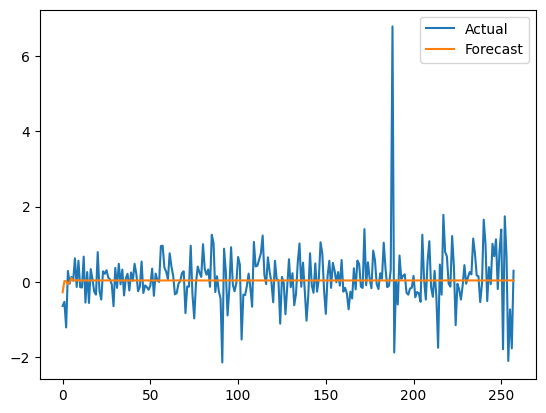

In [350]:
import matplotlib.pyplot as plt

plt.plot(test_data[:,0], label='Actual')
plt.plot(forecast_df['high'].values, label='Forecast')
plt.legend()
plt.show()

In [ ]:
model=VARMAX(train_data,order=(0,4))
result=model.fit()
predictions=result.predict(
    start=len(x_train),
    end=len(x_train)+len(x_test)-1,
    dynamic=False
)

In [ ]:
plt.figure(figsize=(10,7))
plt.plot(x_test.index,x_test,label='test data')
plt.plot(x_test.index,predictions,label='predicted data')
plt.xlabel('date')
plt.ylabel('open price')
plt.legend()
plt.show()
print(f"rmse error {np.sqrt(mean_squared_error(x_test,predictions))}")

In [352]:
window_size=20


In [365]:
data=pd.read_csv("MicrosoftStock.csv")

In [366]:
data.head()

,index,date,open,high,low,close,volume,Name
0,390198,2013-02-08,27.35,27.71,27.31,27.55,33318306,MSFT
1,390199,2013-02-11,27.65,27.92,27.50,27.86,32247549,MSFT
2,390200,2013-02-12,27.88,28.00,27.75,27.88,35990829,MSFT
3,390201,2013-02-13,27.93,28.11,27.88,28.03,41715530,MSFT
4,390202,2013-02-14,27.92,28.06,27.87,28.04,32663174,MSFT


In [367]:
# data['date']=pd.to_datetime(data['date'])
# data['year']=pd.to_datetime(data['date']).dt.year
# data['month']=pd.to_datetime(data['date']).dt.month
# data['date']=pd.to_datetime(data['date']).dt.day

In [368]:
data.head()

,index,date,open,high,low,close,volume,Name
0,390198,2013-02-08,27.35,27.71,27.31,27.55,33318306,MSFT
1,390199,2013-02-11,27.65,27.92,27.50,27.86,32247549,MSFT
2,390200,2013-02-12,27.88,28.00,27.75,27.88,35990829,MSFT
3,390201,2013-02-13,27.93,28.11,27.88,28.03,41715530,MSFT
4,390202,2013-02-14,27.92,28.06,27.87,28.04,32663174,MSFT


In [369]:
data.drop(columns=['index'],inplace=True)

In [370]:
data.set_index('date',inplace=True)

In [371]:
window_size = 20

# Simple Moving Average (SMA)
data['SMA'] = data['close'].rolling(window=window_size).mean()

# Weighted Moving Average (WMA)
weights = np.arange(1, window_size + 1)

data['WMA'] = data['close'].rolling(window_size).apply(
    lambda price: np.dot(price, weights) / weights.sum(),
    raw=True
)

# Exponential Moving Average (EMA)
data['EMA'] = data['close'].ewm(span=window_size).mean()

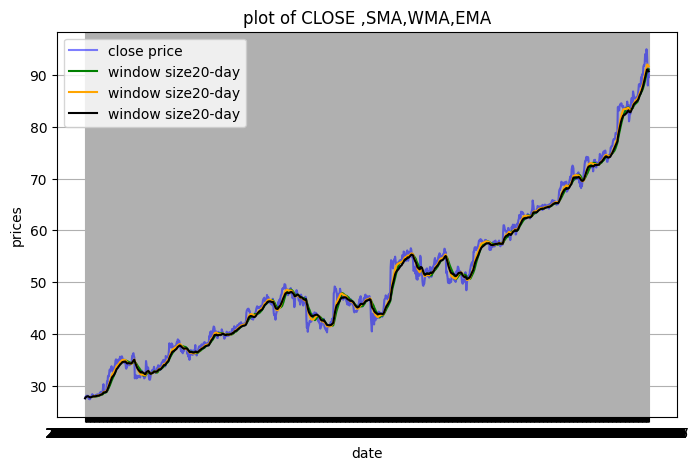

In [374]:
# plt.figure(figsize=(8,5))
# plt.plot(data.index,data['close'],label='close price',color='blue',alpha=0.5)
# plt.plot(data.index,data['SMA'],label=f'window size{window_size}-day',color='green')
# plt.plot(data.index,data['WMA'],label=f'window size{window_size}-day',color='orange')
# plt.plot(data.index,data['EMA'],label=f'window size{window_size}-day',color='black')
# plt.title("plot of CLOSE ,SMA,WMA,EMA")
# plt.xlabel("date")
# plt.ylabel("prices")
# plt.legend()
# plt.grid()
# plt.show()
          

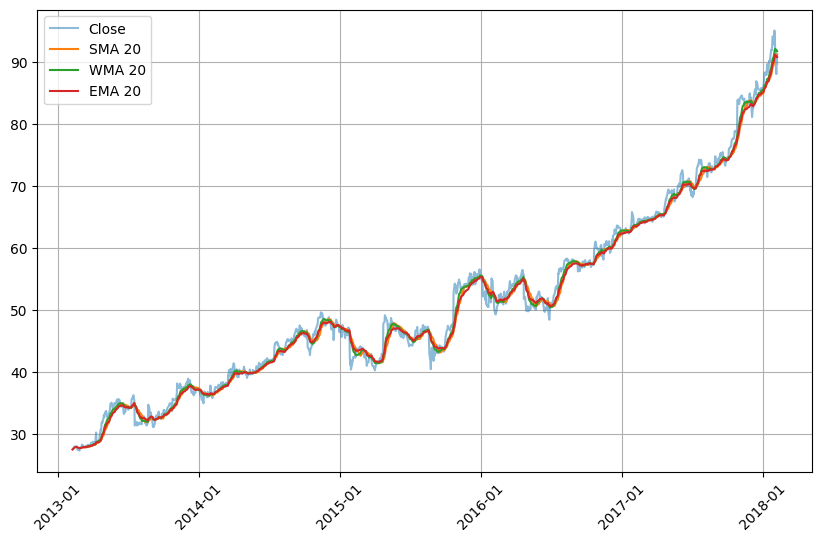

In [376]:
import matplotlib.dates as mdates
data.index = pd.to_datetime(data.index)
data = data.sort_index()

plt.figure(figsize=(10,6))

plt.plot(data.index, data['close'], label='Close', alpha=0.5)
plt.plot(data.index, data['SMA'], label=f'SMA {window_size}')
plt.plot(data.index, data['WMA'], label=f'WMA {window_size}')
plt.plot(data.index, data['EMA'], label=f'EMA {window_size}')

plt.gca().xaxis.set_major_locator(mdates.AutoDateLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

plt.xticks(rotation=45)

plt.legend()
plt.grid()
plt.show()

C:\Users\Mcc\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\Mcc\AppData\Local\Programs\Python\Python313\Lib\site-packages\pandas\util\_decorators.py:213: EstimationWarning: Model has no free parameters to estimate. Set optimized=False to suppress this warning
  return func(*args, **kwargs)
C:\Users\Mcc\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\Mcc\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency informa

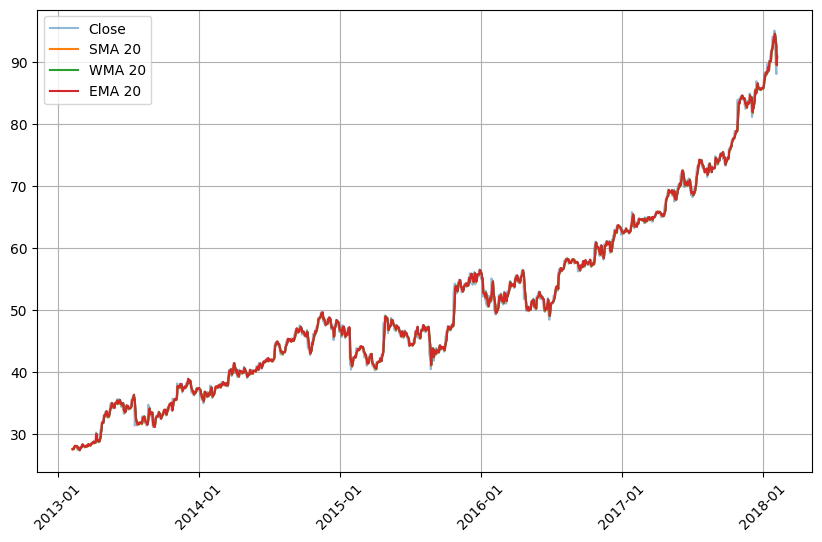

In [379]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing,SimpleExpSmoothing
close_price=data['close']
ses_model=SimpleExpSmoothing(close_price).fit(smoothing_level=0.7)
data['ses_data']=ses_model.fittedvalues

#double exponential smoothing
des_model=ExponentialSmoothing(close_price,trend='add').fit(smoothing_level=0.7)
data['des_data']=des_model.fittedvalues

tes_model=ExponentialSmoothing(close_price,trend='add',seasonal='add',seasonal_periods=12).fit(smoothing_level=0.7)
data['tes_data']=tes_model.fittedvalues


data.index = pd.to_datetime(data.index)
data = data.sort_index()

plt.figure(figsize=(10,6))

plt.plot(data.index, data['close'], label='Close', alpha=0.5)
plt.plot(data.index, data['ses_data'], label=f'SMA {window_size}')
plt.plot(data.index, data['des_data'], label=f'WMA {window_size}')
plt.plot(data.index, data['tes_data'], label=f'EMA {window_size}')

plt.gca().xaxis.set_major_locator(mdates.AutoDateLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

plt.xticks(rotation=45)

plt.legend()
plt.grid()
plt.show()

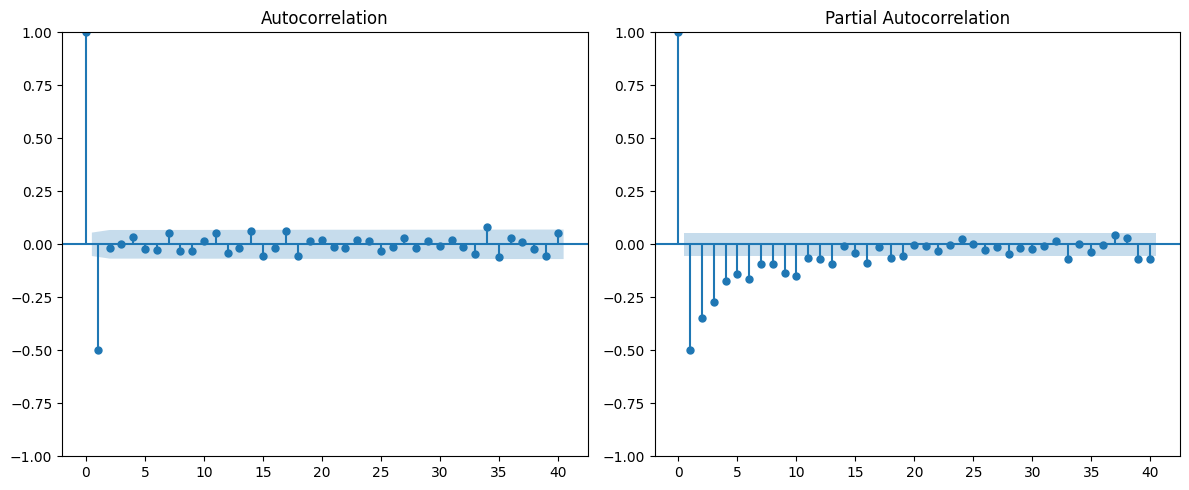

In [380]:
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plot_acf(data['close'].diff().diff().dropna(), lags=40, ax=plt.gca())

plt.subplot(1,2,2)
plot_pacf(data['close'].diff().diff().dropna(), lags=40, ax=plt.gca())

plt.tight_layout()
plt.show()